# Multimodal XAI Framework for Real Estate Valuation
---
## SHapley Additive exPlanations (SHAP) Analysis
##


In [ ]:
# Environment Setup
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

BASE       = '/content/drive/MyDrive/SRED_thesis'
OUTPUT_DIR = f'{BASE}/results'
SHAP_DIR   = f'{BASE}/shap_outputs'

import os
os.makedirs(SHAP_DIR, exist_ok=True)

shap.initjs()
print("Ready.")

Mounted at /content/drive


Ready.


In [ ]:
# Load Models & Aligned Data
m1 = joblib.load(f'{OUTPUT_DIR}/model_lgbm_tabular.pkl')
m3 = joblib.load(f'{OUTPUT_DIR}/model_lgbm_multimodal.pkl')

train_full = pd.read_csv(f'{OUTPUT_DIR}/train_full_aligned.csv')
test_full  = pd.read_csv(f'{OUTPUT_DIR}/test_full_aligned.csv')

TABULAR_FEATURES = ['living_space', 'rooms', 'lat', 'lon']
pca_cols         = [f'pca_{i}' for i in range(128)]
MULTIMODAL       = TABULAR_FEATURES + pca_cols

X_train_tab = train_full[TABULAR_FEATURES].values
X_test_tab  = test_full[TABULAR_FEATURES].values
X_train_mm  = train_full[MULTIMODAL].values
X_test_mm   = test_full[MULTIMODAL].values
y_test      = test_full['log_price'].values

print(f"Test set: {len(test_full):,} listings")
print(f"Multimodal features: {len(MULTIMODAL)}")

Test set: 1,109 listings
Multimodal features: 132


In [ ]:
# Compute SHAP values for tabular model
print("Computing SHAP values — tabular model...")
explainer_tab  = shap.TreeExplainer(m1)
shap_vals_tab  = explainer_tab.shap_values(X_test_tab)
expected_tab   = explainer_tab.expected_value

print(f"SHAP matrix shape: {shap_vals_tab.shape}")
print(f"Base value (expected log price): {expected_tab:.4f}")
print(f"Base value (CHF):                {np.exp(expected_tab):,.0f}")

Computing SHAP values — tabular model...
SHAP matrix shape: (1109, 4)
Base value (expected log price): 7.4092
Base value (CHF):                1,651


In [ ]:
# Compute SHAP values for multimodal model
print("Computing SHAP values — multimodal model...")
explainer_mm  = shap.TreeExplainer(m3)
shap_vals_mm  = explainer_mm.shap_values(X_test_mm)
expected_mm   = explainer_mm.expected_value

print(f"SHAP matrix shape: {shap_vals_mm.shape}")
print(f"Base value (expected log price): {expected_mm:.4f}")
print(f"Base value (CHF):                {np.exp(expected_mm):,.0f}")


np.save(f'{SHAP_DIR}/shap_vals_mm.npy',  shap_vals_mm)
np.save(f'{SHAP_DIR}/shap_vals_tab.npy', shap_vals_tab)
print("SHAP values saved.")

Computing SHAP values — multimodal model...
SHAP matrix shape: (1109, 132)
Base value (expected log price): 7.4098
Base value (CHF):                1,652
SHAP values saved.


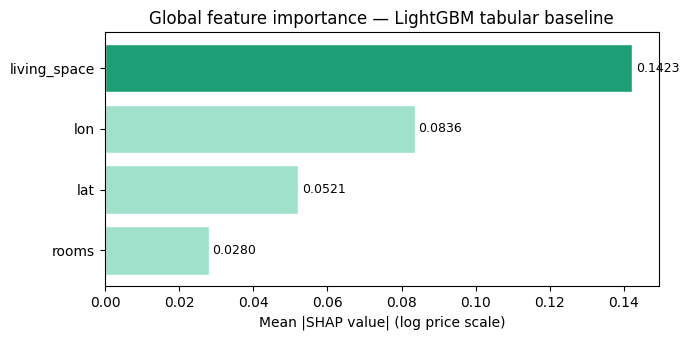

Figure 6 saved.


In [ ]:
# Global SHAP — tabular model bar chart
# Shows mean absolute SHAP value per feature.
mean_shap_tab = np.abs(shap_vals_tab).mean(axis=0)
tab_importance = pd.Series(mean_shap_tab, index=TABULAR_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ['#1D9E75' if v == tab_importance.max() else '#9FE1CB' for v in tab_importance]
bars = ax.barh(tab_importance.index, tab_importance.values, color=colors, edgecolor='white')
ax.set_xlabel('Mean |SHAP value| (log price scale)')
ax.set_title('Global feature importance — LightGBM tabular baseline', fontsize=12)
ax.axvline(x=0, color='black', linewidth=0.5)

for bar, val in zip(bars, tab_importance.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{SHAP_DIR}/fig6_shap_tabular_global.png', bbox_inches='tight')
plt.show()
print("Figure 6 saved.")

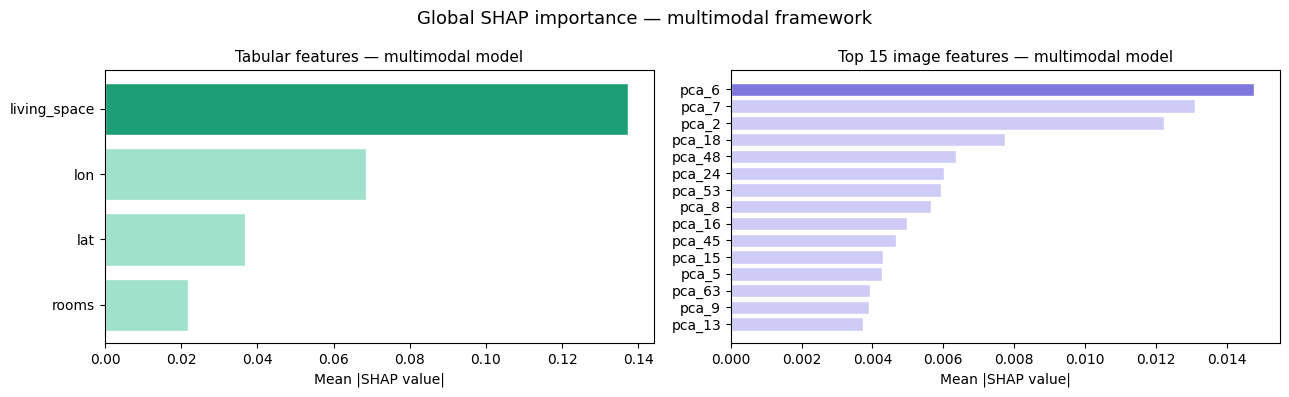

Figure 7 saved.


In [ ]:
# Global SHAP — multimodal and tabular features split
mean_shap_mm_all = np.abs(shap_vals_mm).mean(axis=0)
tab_in_mm = pd.Series(mean_shap_mm_all[:4], index=TABULAR_FEATURES).sort_values()
img_in_mm = pd.Series(mean_shap_mm_all[4:], index=pca_cols)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: tabular features in multimodal model
colors_tab = ['#1D9E75' if v == tab_in_mm.max() else '#9FE1CB' for v in tab_in_mm]
axes[0].barh(tab_in_mm.index, tab_in_mm.values, color=colors_tab, edgecolor='white')
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('Tabular features — multimodal model', fontsize=11)

# Right: top 15 image features in multimodal model
top_img = img_in_mm.sort_values(ascending=False).head(15).sort_values()
colors_img = ['#7F77DD' if v == top_img.max() else '#CECBF6' for v in top_img]
axes[1].barh(top_img.index, top_img.values, color=colors_img, edgecolor='white')
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].set_title('Top 15 image features — multimodal model', fontsize=11)

plt.suptitle('Global SHAP importance — multimodal framework', fontsize=13)
plt.tight_layout()
plt.savefig(f'{SHAP_DIR}/fig7_shap_multimodal_global.png', bbox_inches='tight')
plt.show()
print("Figure 7 saved.")

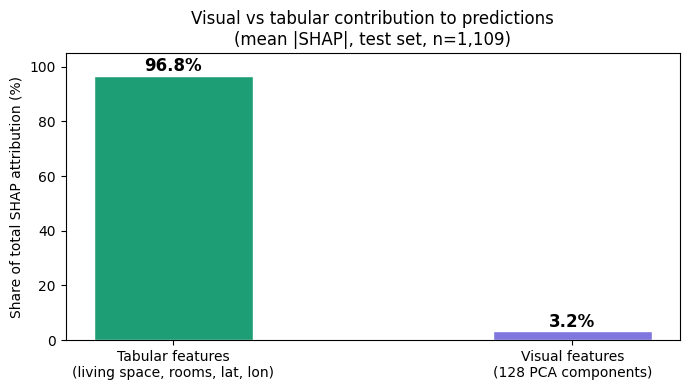

Figure 8 saved.


In [ ]:
# Visual vs tabular SHAP contribution
tab_total = np.abs(shap_vals_mm[:, :4]).mean()
img_total = np.abs(shap_vals_mm[:, 4:]).mean()
total     = tab_total + img_total

labels = ['Tabular features\n(living space, rooms, lat, lon)',
          'Visual features\n(128 PCA components)']
values = [tab_total / total * 100, img_total / total * 100]
colors = ['#1D9E75', '#7F77DD']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, values, color=colors, edgecolor='white', width=0.4)
ax.set_ylabel('Share of total SHAP attribution (%)')
ax.set_title('Visual vs tabular contribution to predictions\n(mean |SHAP|, test set, n=1,109)', fontsize=12)
ax.set_ylim(0, 105)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1.5,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{SHAP_DIR}/fig8_visual_vs_tabular_shap.png', bbox_inches='tight')
plt.show()
print("Figure 8 saved.")

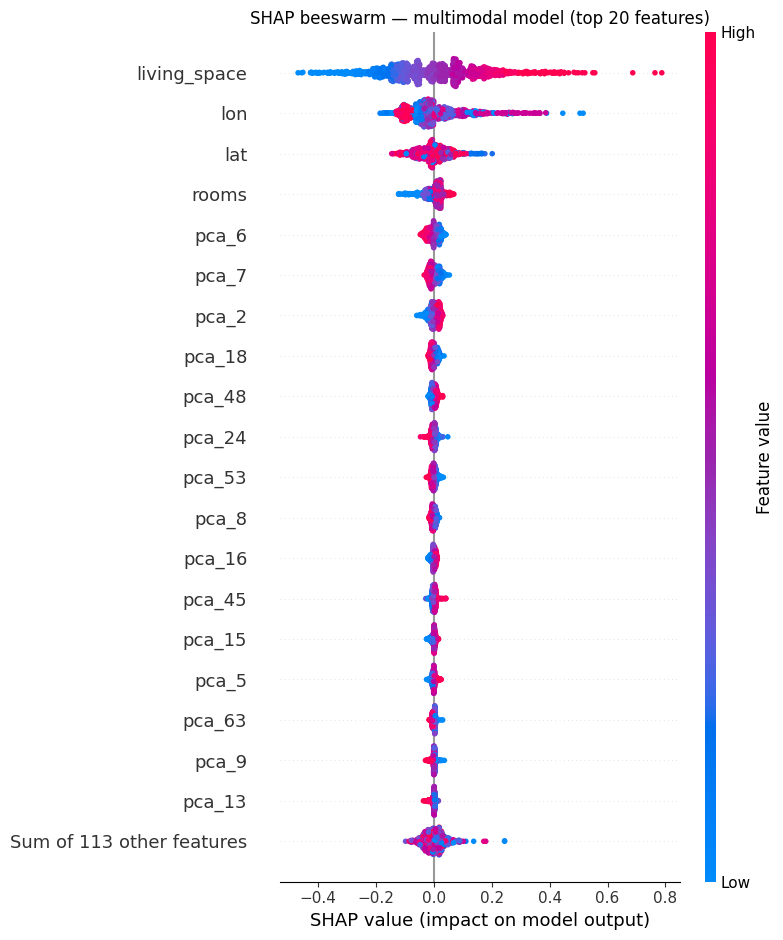

Figure 9 saved.


In [ ]:
# SHAP beeswarm plot
# Shows distribution of SHAP values across all test samples where each dot is one property. Color = feature value (high/low).

# Build explanation object for shap plotting
explanation_mm = shap.Explanation(
    values       = shap_vals_mm,
    base_values  = np.full(len(shap_vals_mm), expected_mm),
    data         = X_test_mm,
    feature_names= MULTIMODAL
)

fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.beeswarm(explanation_mm, max_display=20, show=False)
plt.title('SHAP beeswarm — multimodal model (top 20 features)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{SHAP_DIR}/fig9_shap_beeswarm.png', bbox_inches='tight')
plt.show()
print("Figure 9 saved.")

=== PER-PREDICTION VISUAL SHAP SHARE ===
Mean:   54.2%
Median: 54.0%
Max:    92.6%
Min:    24.2%
Std:    11.7%

Properties where visual SHAP > 10%: 1109
Properties where visual SHAP > 20%: 1109
Properties where visual SHAP > 30%: 1096


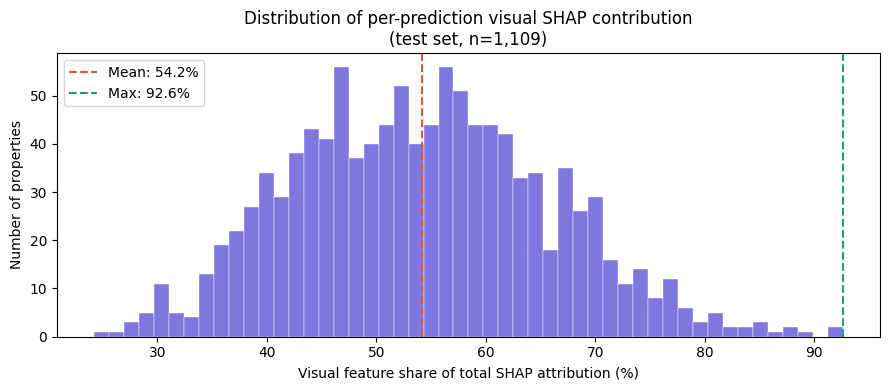

Figure 10 saved.


In [ ]:
# er-prediction visual SHAP distribution
# Key finding: even though AVERAGE visual SHAP is 3.5%,
# individual predictions vary widely.
# Some properties have much higher visual contribution.
# This motivates the Identical Twins case study.
_
# Compute per-prediction visual share
per_pred_tab = np.abs(shap_vals_mm[:, :4]).sum(axis=1)
per_pred_img = np.abs(shap_vals_mm[:, 4:]).sum(axis=1)
per_pred_total = per_pred_tab + per_pred_img
per_pred_img_share = per_pred_img / per_pred_total * 100

print("=== PER-PREDICTION VISUAL SHAP SHARE ===")
print(f"Mean:   {per_pred_img_share.mean():.1f}%")
print(f"Median: {np.median(per_pred_img_share):.1f}%")
print(f"Max:    {per_pred_img_share.max():.1f}%")
print(f"Min:    {per_pred_img_share.min():.1f}%")
print(f"Std:    {per_pred_img_share.std():.1f}%")
print(f"\nProperties where visual SHAP > 10%: {(per_pred_img_share > 10).sum()}")
print(f"Properties where visual SHAP > 20%: {(per_pred_img_share > 20).sum()}")
print(f"Properties where visual SHAP > 30%: {(per_pred_img_share > 30).sum()}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(per_pred_img_share, bins=50, color='#7F77DD',
        edgecolor='white', linewidth=0.3)
ax.axvline(per_pred_img_share.mean(), color='#D85A30',
           linestyle='--', linewidth=1.5,
           label=f'Mean: {per_pred_img_share.mean():.1f}%')
ax.axvline(per_pred_img_share.max(), color='#1D9E75',
           linestyle='--', linewidth=1.5,
           label=f'Max: {per_pred_img_share.max():.1f}%')
ax.set_xlabel('Visual feature share of total SHAP attribution (%)')
ax.set_ylabel('Number of properties')
ax.set_title('Distribution of per-prediction visual SHAP contribution\n(test set, n=1,109)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(f'{SHAP_DIR}/fig10_visual_shap_distribution.png', bbox_inches='tight')
plt.show()
print("Figure 10 saved.")


=== Highest visual SHAP contribution ===
  listing_id:    6253596
  living_space:  83 m²
  rooms:         3.5
  True price:    CHF 1,560/month
  Predicted:     CHF 1,584/month
  Visual SHAP:   92.6%


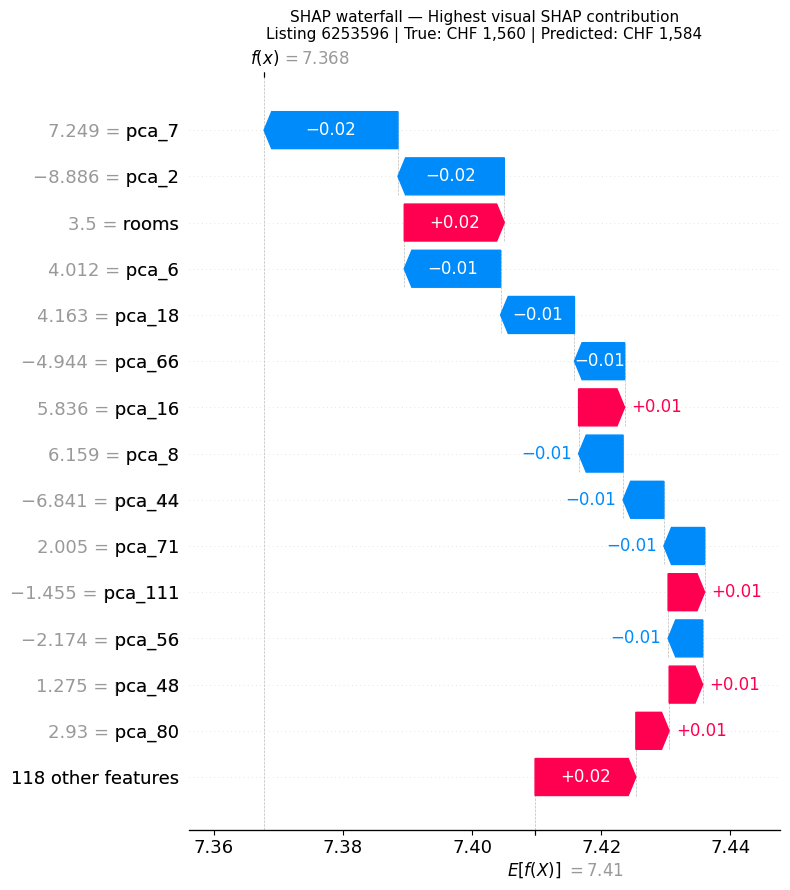

  Saved: fig11a_waterfall_high_visual.png

=== Lowest visual SHAP contribution ===
  listing_id:    6384949
  living_space:  45 m²
  rooms:         2.0
  True price:    CHF 1,275/month
  Predicted:     CHF 1,490/month
  Visual SHAP:   24.2%


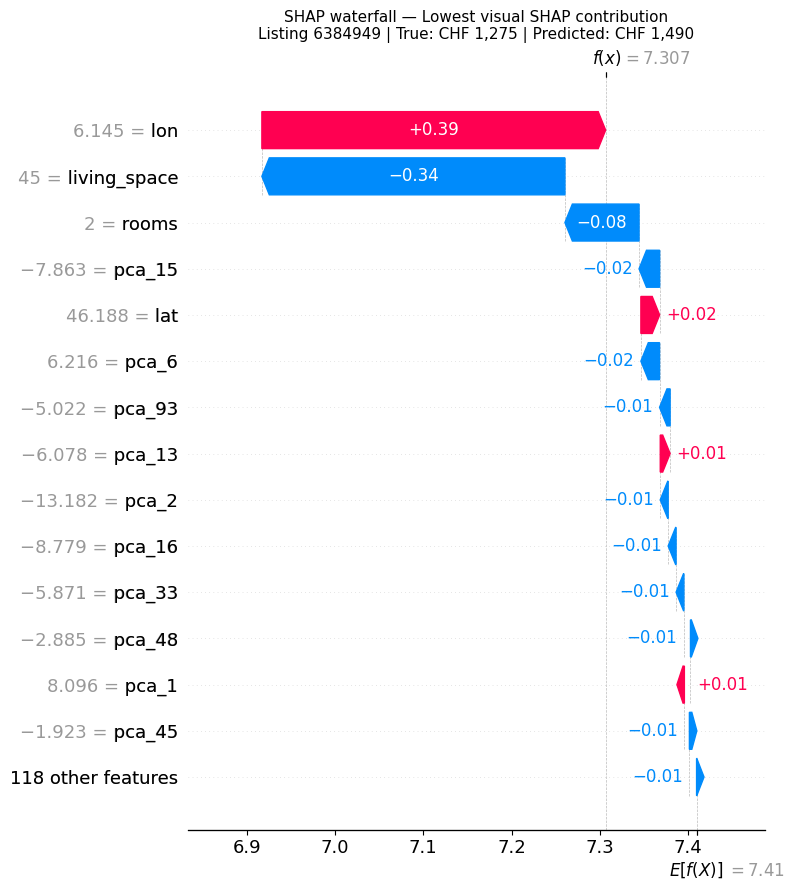

  Saved: fig11b_waterfall_low_visual.png


In [ ]:
# Individual waterfall plots

# Find highest visual SHAP property
idx_high_visual = per_pred_img_share.argmax()
idx_low_visual  = per_pred_img_share.argmin()

for idx, label, fname in [
    (idx_high_visual, 'Highest visual SHAP contribution', 'fig11a_waterfall_high_visual'),
    (idx_low_visual,  'Lowest visual SHAP contribution',  'fig11b_waterfall_low_visual')
]:
    prop = test_full.iloc[idx]
    pred_price = np.exp(m3.predict(X_test_mm[idx:idx+1])[0])
    true_price = np.exp(y_test[idx])

    print(f"\n=== {label} ===")
    print(f"  listing_id:    {int(prop['listing_id'])}")
    print(f"  living_space:  {prop['living_space']:.0f} m²")
    print(f"  rooms:         {prop['rooms']}")
    print(f"  True price:    CHF {true_price:,.0f}/month")
    print(f"  Predicted:     CHF {pred_price:,.0f}/month")
    print(f"  Visual SHAP:   {per_pred_img_share[idx]:.1f}%")

    # Waterfall plot — top 15 features only for readability
    exp_single = shap.Explanation(
        values      = shap_vals_mm[idx],
        base_values = expected_mm,
        data        = X_test_mm[idx],
        feature_names = MULTIMODAL
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    shap.plots.waterfall(exp_single, max_display=15, show=False)
    plt.title(f'SHAP waterfall — {label}\nListing {int(prop["listing_id"])} | True: CHF {true_price:,.0f} | Predicted: CHF {pred_price:,.0f}', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{SHAP_DIR}/{fname}.png', bbox_inches='tight')
    plt.show()
    print(f"  Saved: {fname}.png")

In [ ]:
# Saving
# Saved per-prediction visual share with listing_ids
visual_shap_df = pd.DataFrame({
    'listing_id':      test_full['listing_id'].values,
    'visual_shap_pct': per_pred_img_share,
    'living_space':    test_full['living_space'].values,
    'rooms':           test_full['rooms'].values,
    'lat':             test_full['lat'].values,
    'lon':             test_full['lon'].values,
    'true_log_price':  y_test,
    'true_price_chf':  np.exp(y_test)
}).sort_values('visual_shap_pct', ascending=False)

visual_shap_df.to_csv(f'{SHAP_DIR}/visual_shap_per_prediction.csv', index=False)

print("=== TOP 10 PROPERTIES BY VISUAL SHAP ===")
print(visual_shap_df.head(10)[['listing_id', 'visual_shap_pct',
                                'living_space', 'rooms',
                                'true_price_chf']].to_string(index=False))
print(f"\nSaved visual_shap_per_prediction.csv")
print("Notebook 4 complete.")

=== TOP 10 PROPERTIES BY VISUAL SHAP ===
 listing_id  visual_shap_pct  living_space  rooms  true_price_chf
    6253596        92.580827            83    3.5          1560.0
    6018366        91.583863            87    4.5          1900.0
    5229369        88.544364            84    3.5          1940.0
    6388827        87.480839            90    4.5          1480.0
    6345728        87.262537            81    3.5          1870.0
    6328609        85.818506            89    4.0          1481.0
    6322173        85.062714            88    4.5          1585.0
    6313345        84.719522            85    4.5          1350.0
    3427300        84.679720            81    2.5          1480.0
    6357423        83.628897            84    3.5          1680.0

Saved visual_shap_per_prediction.csv
Notebook 4 complete.
